读取`maipulability.yaml`, 得到最大的 manipulability 对应的 Contact selection

In [50]:
import numpy as np
import yaml
import heapq
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [4]:

# Load the YAML file into a dictionary.
with open('manipulability.yaml', 'r') as file:
    data = yaml.load(file, Loader=yaml.FullLoader)

# Specify the number of top items you want.
N = 10  # Change N as needed

# Use heapq.nlargest to get a list of (key, value) tuples with the highest values.
top_n = heapq.nlargest(N, data.items(), key=lambda item: item[1])

print(f"Top {N} largest values and corresponding keys:")
for key, value in top_n:
    print(f"Key: {key}, Value: {value}")

Top 10 largest values and corresponding keys:
Key: (114, 116), Value: 0.18549352771020222
Key: (113, 116), Value: 0.17882236129751278
Key: (113, 117), Value: 0.16745778676457246
Key: (113, 115), Value: 0.16657540630976536
Key: (114, 117), Value: 0.15821523045312663
Key: (112, 116), Value: 0.15503200824165417
Key: (113, 118), Value: 0.15061656301676835
Key: (88, 116), Value: 0.14863630233745498
Key: (99, 116), Value: 0.14742843577112125
Key: (112, 117), Value: 0.14669616972546828


In [5]:
# Load the YAML file into a dictionary.
with open('deform_strain.yaml', 'r') as file:
    data = yaml.load(file, Loader=yaml.FullLoader)

# Specify the number of top items you want.
N = 10  # Change N as needed

# Use heapq.nlargest to get a list of (key, value) tuples with the highest values.
top_n = heapq.nsmallest(N, data.items(), key=lambda item: item[1])

print(f"Top {N} largest values and corresponding keys:")
for key, value in top_n:
    print(f"Key: {key}, Value: {value}")

Top 10 largest values and corresponding keys:
Key: (99, 117), Value: 3.952479e-05
Key: (112, 117), Value: 4.418165e-05
Key: (113, 117), Value: 4.432247e-05
Key: (99, 118), Value: 4.446631e-05
Key: (88, 117), Value: 4.75253e-05
Key: (99, 109), Value: 4.791974e-05
Key: (99, 119), Value: 4.854157e-05
Key: (111, 117), Value: 4.974689e-05
Key: (112, 118), Value: 5.231498e-05
Key: (98, 112), Value: 5.394958e-05


In [44]:
with open('manipulability2.yaml', 'r') as file:
    mani = yaml.load(file, Loader=yaml.FullLoader)

with open('deform_strain2.yaml', 'r') as file:
    deform = yaml.load(file, Loader=yaml.FullLoader)

manipulability = []
deformation_energy = []
common_keys = []
for key in deform:
    if deform[key] < 2.e-5:
        if key in mani:
            common_keys.append(key)
            manipulability.append(mani[key])
            deformation_energy.append(deform[key])
        else:
            print(f"Warning: Key '{key}' found in deform but not in mani.")
        
# Convert lists to numpy arrays for further processing
manipulability = np.array(manipulability)
deformation_energy = np.array(deformation_energy) * 1.e4

用于进行初步的回归分析

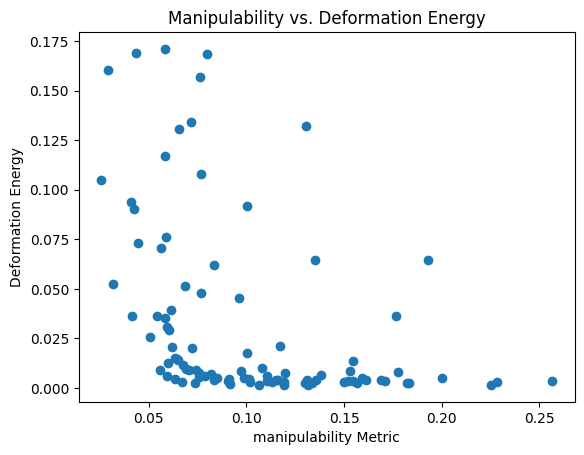

Log Fit RMSE: 4.041128e-02


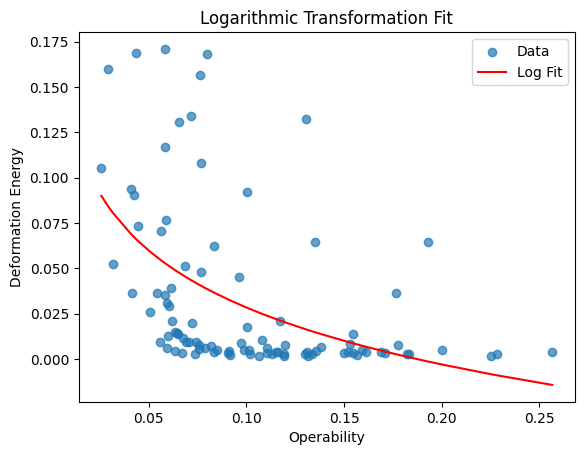

Reciprocal Fit RMSE: 3.966347e-02


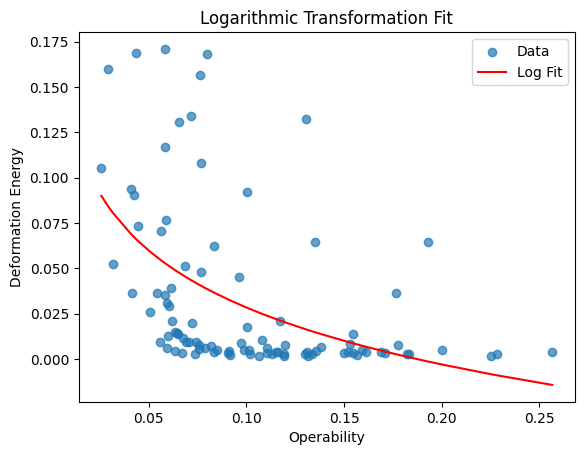

Pearson correlation coefficient: -0.602
p-value: 1.097820e-10


In [45]:
# Plot the data to visually inspect the relationship
plt.scatter(manipulability, deformation_energy)
plt.xlabel('manipulability Metric')
plt.ylabel('Deformation Energy')
plt.title('Manipulability vs. Deformation Energy')
plt.show()


# --- Logarithmic Transformation ---
# Here we assume operability values are positive so that np.log is defined.
manipulability_log = np.log(manipulability)
# Fit a linear model on the log-transformed operability vs. deformation energy.
coeff_log = np.polyfit(manipulability_log, deformation_energy, 1)
# Create fitted values using the linear model.
fitted_deformation_log = np.polyval(coeff_log, manipulability_log)
mse_log = mean_squared_error(deformation_energy, fitted_deformation_log)
rmse_log = np.sqrt(mse_log)
print(f'Log Fit RMSE: {rmse_log:e}')

plt.scatter(manipulability, deformation_energy, label='Data', alpha=0.7)
# For plotting the fitted line, sort the x-values
order = np.argsort(manipulability)
plt.plot(manipulability[order], fitted_deformation_log[order], color='red', label='Log Fit')
plt.xlabel('Operability')
plt.ylabel('Deformation Energy')
plt.title('Logarithmic Transformation Fit')
plt.legend()
plt.show()


# --- Reciprocal Transformation ---
# We assume operability values are non-zero.
operability_reciprocal = 1.0 / manipulability
# Fit a linear model on the reciprocal-transformed operability vs. deformation energy.
coeff_rec = np.polyfit(operability_reciprocal, deformation_energy, 1)
fitted_deformation_rec = np.polyval(coeff_rec, operability_reciprocal)
# Calculate RMSE for the reciprocal model
mse_rec = mean_squared_error(deformation_energy, fitted_deformation_rec)
rmse_rec = np.sqrt(mse_rec)
print(f'Reciprocal Fit RMSE: {rmse_rec:e}')

plt.scatter(manipulability, deformation_energy, label='Data', alpha=0.7)
order = np.argsort(manipulability)
plt.plot(manipulability[order], fitted_deformation_log[order], color='red', label='Log Fit')
plt.xlabel('Operability')
plt.ylabel('Deformation Energy')
plt.title('Logarithmic Transformation Fit')
plt.legend()
plt.show()

# Compute Spearmanr correlation coefficient
corr, p_val = spearmanr(manipulability, deformation_energy)
print(f'Spearmanr correlation coefficient: {corr:.3f}')
print(f'p-value: {p_val:e}')

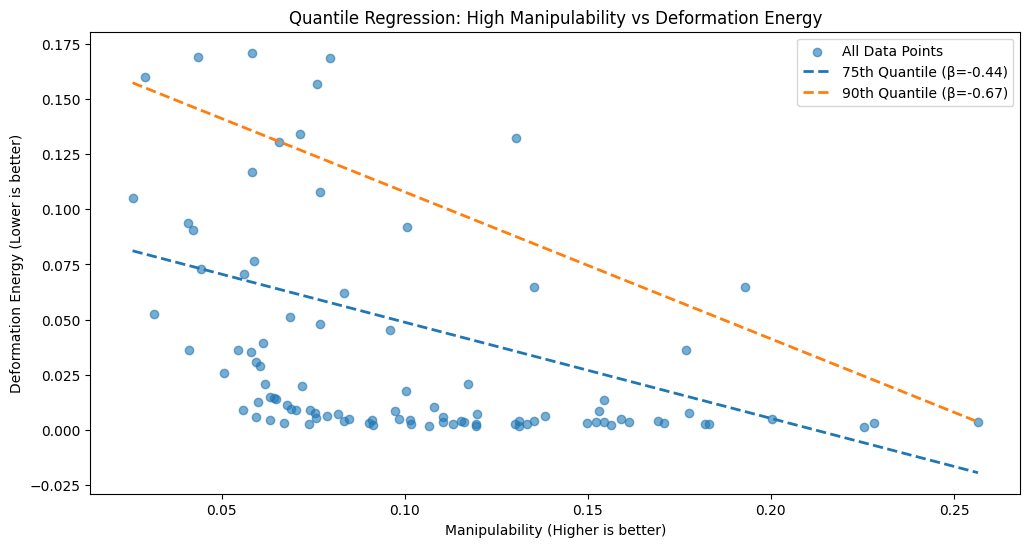


局部相关性分析结果:
 Threshold  Spearman ρ Quantile
  0.090364   -0.141998     50th
  0.131259   -0.059130     75th
  0.170125   -0.236364     90th


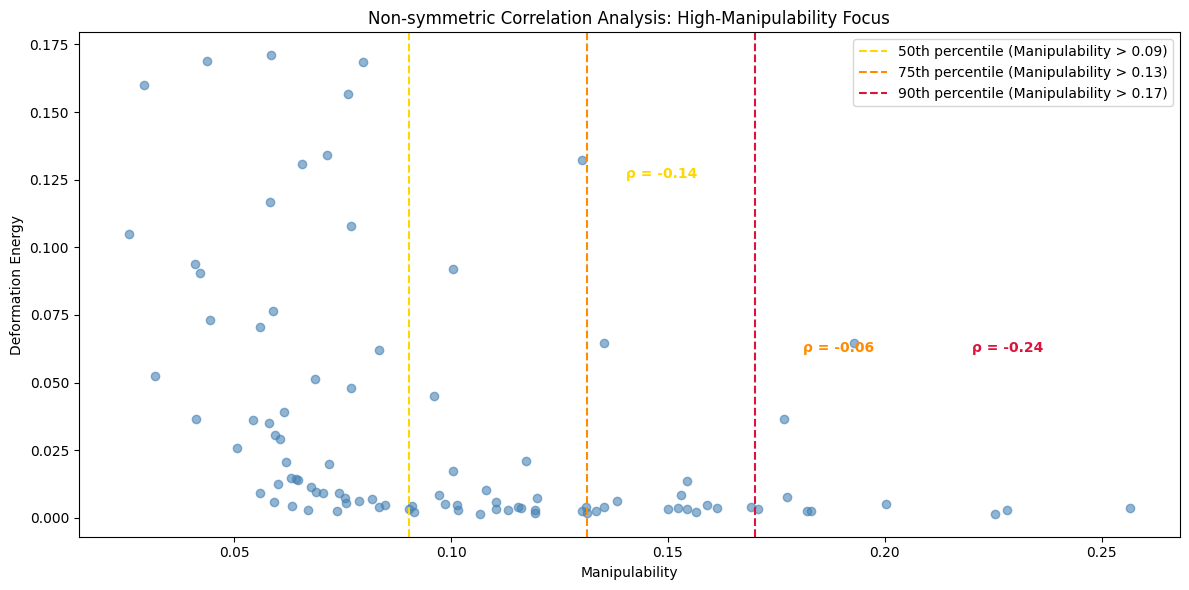


分位数回归显著性检验示例 (90th percentile):
                            OLS Regression Results                            
Dep. Variable:     deformation_energy   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                 -0.062
Method:                 Least Squares   F-statistic:                    0.4773
Date:                Fri, 14 Mar 2025   Prob (F-statistic):              0.509
Time:                        10:19:59   Log-Likelihood:                 25.294
No. Observations:                  10   AIC:                            -46.59
Df Residuals:                       8   BIC:                            -45.98
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const      

/home/yiliao/anaconda3/envs/py3.8/lib/python3.8/site-packages/scipy/stats/_stats_py.py:1772: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [48]:
# 步骤0：创建DataFrame并排序（按manipulability升序）
df = pd.DataFrame({
    'manipulability': manipulability,
    'deformation_energy': deformation_energy
}).sort_values('manipulability')

df[['manipulability', 'deformation_energy']].describe()

# =========================================================================
# 步骤1：分位数回归分析（关注高manipulability区域）
# =========================================================================
quantiles = [0.75, 0.90]  # 重点关注高可操控性区域

plt.figure(figsize=(12, 6))
plt.scatter(df['manipulability'], df['deformation_energy'], 
            alpha=0.6, label='All Data Points')

# 分位数回归分析
for q in quantiles:
    X = sm.add_constant(df['manipulability'])  # 添加截距项
    model = sm.QuantReg(df['deformation_energy'], X)
    res = model.fit(q=q)
    
    # 获取预测值并绘图
    df[f'pred_q{q}'] = res.predict(X)
    plt.plot(df['manipulability'], df[f'pred_q{q}'], 
             linestyle='--', linewidth=2,
             label=f'{int(q*100)}th Quantile (β={res.params[1]:.2f})')

plt.xlabel('Manipulability (Higher is better)')
plt.ylabel('Deformation Energy (Lower is better)')
plt.legend()
plt.title('Quantile Regression: High Manipulability vs Deformation Energy')
plt.show()

# =========================================================================
# 步骤2：局部相关性分析（高manipulability区域）
# =========================================================================
def local_spearman(df, threshold):
    """计算manipulability高于阈值时的Spearman相关系数"""
    subset = df[df['manipulability'] > threshold]
    return subset[['manipulability', 'deformation_energy']].corr(
        method='spearman'
    ).iloc[0, 1]

# 计算不同阈值下的局部相关系数
thresholds = [np.quantile(df['manipulability'], q) for q in [0.5, 0.75, 0.9]]
local_corrs = [local_spearman(df, t) for t in thresholds]

# 展示结果
results = pd.DataFrame({
    'Threshold': thresholds,
    'Spearman ρ': local_corrs,
    'Quantile': ['50th', '75th', '90th']
})
print("\n局部相关性分析结果:")
print(results.to_string(index=False))

# =========================================================================
# 步骤3：可视化关键阈值区域
# =========================================================================
plt.figure(figsize=(12, 6))
plt.scatter(df['manipulability'], df['deformation_energy'], 
           alpha=0.6, c='steelblue')

# 标记不同阈值区域
colors = ['gold', 'darkorange', 'crimson']
for i, (t, q_label) in enumerate(zip(thresholds, ['50th', '75th', '90th'])):
    plt.axvline(t, color=colors[i], linestyle='--', linewidth=1.5,
                label=f'{q_label} percentile (Manipulability > {t:.2f})')
    
    # 标注局部相关系数
    subset = df[df['manipulability'] > t]
    plt.text(t + 0.05, subset['deformation_energy'].max()*0.95,
             f'ρ = {local_corrs[i]:.2f}',
             color=colors[i], fontsize=10, weight='bold')

plt.xlabel('Manipulability')
plt.ylabel('Deformation Energy')
plt.legend(loc='upper right')
plt.title('Non-symmetric Correlation Analysis: High-Manipulability Focus')
plt.tight_layout()
plt.show()

# =========================================================================
# 步骤4：显著性检验（示例：最高分位数区域）
# =========================================================================
print("\n分位数回归显著性检验示例 (90th percentile):")
high_manipulability = df[df['manipulability'] > thresholds[2]]
X_high = sm.add_constant(high_manipulability['manipulability'])
model_high = sm.OLS(high_manipulability['deformation_energy'], X_high)
results_high = model_high.fit()
print(results_high.summary())

marker = [92, 104]

In [83]:
with open('manipulability3.yaml', 'r') as file:
    mani = yaml.load(file, Loader=yaml.FullLoader)

with open('deform_strain3.yaml', 'r') as file:
    deform = yaml.load(file, Loader=yaml.FullLoader)

manipulability = []
deformations = []
common_keys = []
for key in deform:
    if key in mani:
        common_keys.append(key)
        manipulability.append(mani[key])
        deformations.append(deform[key])
    else:
        print(f"Warning: Key '{key}' found in deform but not in mani.")
        
df3 = pd.DataFrame({
    "combined_key": common_keys,
    'manipulability': np.array(manipulability),
    'deformations': np.array(deformations)
}).sort_values('manipulability')

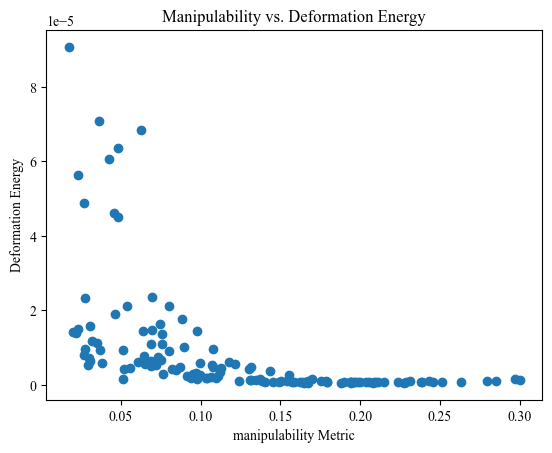

Reciprocal Fit RMSE: 1.241923e-05


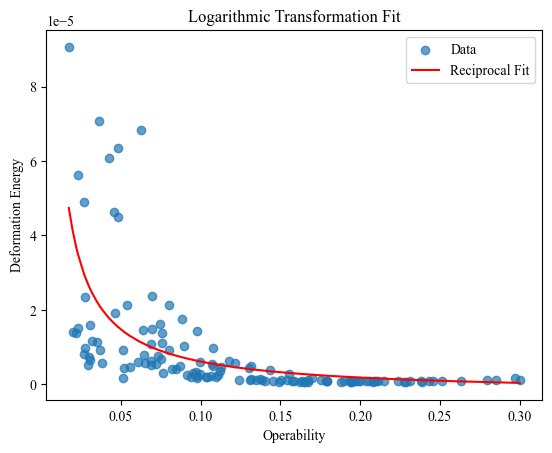

Spearmanr correlation coefficient: -0.861
p-value: 4.738937e-40


In [84]:
# Plot the data to visually inspect the relationship
plt.scatter(df3["manipulability"], df3["deformations"])
plt.xlabel('manipulability Metric')
plt.ylabel('Deformation Energy')
plt.title('Manipulability vs. Deformation Energy')
plt.show()


# --- Logarithmic Transformation ---
# log拟合比反比例函数差，舍去


# --- Reciprocal Transformation ---
# We assume operability values are non-zero.
operability_reciprocal = 1.0 / df3["manipulability"]
# Fit a linear model on the reciprocal-transformed operability vs. deformation energy.
coeff_rec = np.polyfit(operability_reciprocal, df3["deformations"], 1)
fitted_deformation_rec = np.polyval(coeff_rec, operability_reciprocal)
# Calculate RMSE for the reciprocal model
mse_rec = mean_squared_error(df3["deformations"], fitted_deformation_rec)
rmse_rec = np.sqrt(mse_rec)
print(f'Reciprocal Fit RMSE: {rmse_rec:e}')

plt.scatter(df3["manipulability"], df3["deformations"], label='Data', alpha=0.7)
plt.plot(df3["manipulability"], fitted_deformation_rec, color='red', label='Reciprocal Fit')
plt.xlabel('Operability')
plt.ylabel('Deformation Energy')
plt.title('Logarithmic Transformation Fit')
plt.legend()
plt.show()

# Compute Spearmanr correlation coefficient
corr, p_val = spearmanr(df3["manipulability"], df3["deformations"])
print(f'Spearmanr correlation coefficient: {corr:.3f}')
print(f'p-value: {p_val:e}')

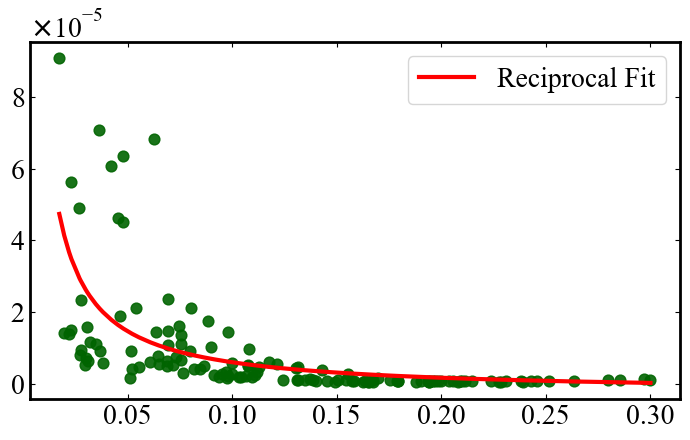

In [85]:
fig = plt.figure(figsize=(7, 4.5), dpi=100)
gs = fig.add_gridspec(1, 1)

ax = fig.add_subplot(gs[0, 0])
ax.scatter(df3["manipulability"], df3["deformations"], alpha=0.9, s=60, c="darkgreen")
# order = np.argsort(manipulability)
ax.plot(df3["manipulability"], fitted_deformation_rec, lw=3, color='red', label='Reciprocal Fit')
# ax.set_xlabel('Manipulability', fontsize=22)
# ax.set_ylabel('Deformation Strain', fontsize=22)
ax.legend(fontsize=20)
ax.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
ax.yaxis.offsetText.set_fontsize(20)
ax.yaxis.get_offset_text().set_fontsize(20)
ax.tick_params(axis='both', which='major', labelsize=20, direction='in', top=True, right=True)
# ax.grid(True)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(2.)

fig.tight_layout()
fig.savefig('mani-deform-1.svg', transparent=True, dpi=300, bbox_inches='tight')

marker = [103, 104]

In [78]:
with open('manipulability4.yaml', 'r') as file:
    mani = yaml.load(file, Loader=yaml.FullLoader)

with open('deform_strain4.yaml', 'r') as file:
    deform = yaml.load(file, Loader=yaml.FullLoader)

manipulability = []
deformations = []
common_keys = []
for key in deform:
    if key in mani:
        common_keys.append(key)
        manipulability.append(mani[key])
        deformations.append(deform[key])
    else:
        print(f"Warning: Key '{key}' found in deform but not in mani.")
        
df4 = pd.DataFrame({
    "combined_key": common_keys,
    'manipulability': np.array(manipulability),
    'deformations': np.array(deformations)
}).sort_values('manipulability')

Reciprocal Fit RMSE: 2.213991e-05


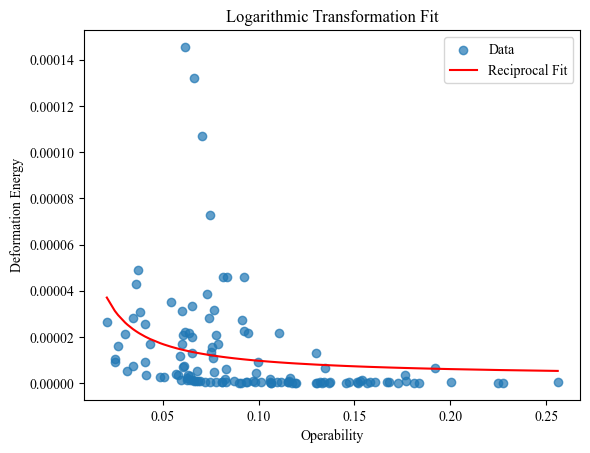

Spearmanr correlation coefficient: -0.654
p-value: 1.740084e-16


In [79]:
# --- Reciprocal Transformation ---
# We assume operability values are non-zero.
operability_reciprocal = 1.0 / df4["manipulability"]
# Fit a linear model on the reciprocal-transformed operability vs. deformation energy.
coeff_rec = np.polyfit(operability_reciprocal, df4["deformations"], 1)
fitted_deformation_rec = np.polyval(coeff_rec, operability_reciprocal)
# Calculate RMSE for the reciprocal model
mse_rec = mean_squared_error(df4["deformations"], fitted_deformation_rec)
rmse_rec = np.sqrt(mse_rec)
print(f'Reciprocal Fit RMSE: {rmse_rec:e}')

plt.scatter(df4["manipulability"], df4["deformations"], label='Data', alpha=0.7)
plt.plot(df4["manipulability"], fitted_deformation_rec, color='red', label='Reciprocal Fit')
plt.xlabel('Operability')
plt.ylabel('Deformation Energy')
plt.title('Logarithmic Transformation Fit')
plt.legend()
plt.show()

# Compute Spearmanr correlation coefficient
corr, p_val = spearmanr(df4["manipulability"], df4["deformations"])
print(f'Spearmanr correlation coefficient: {corr:.3f}')
print(f'p-value: {p_val:e}')

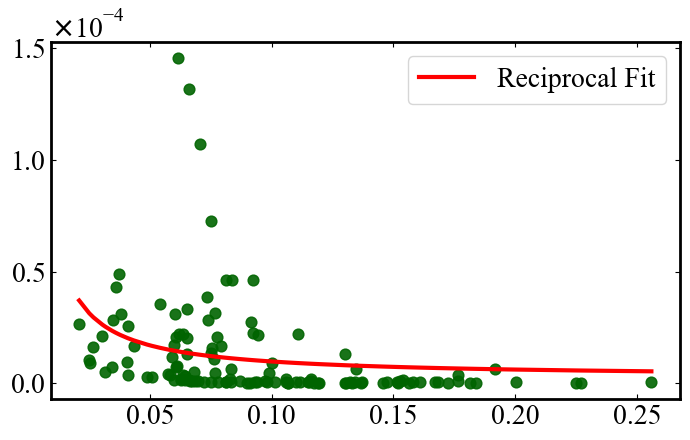

In [81]:
fig = plt.figure(figsize=(7, 4.5), dpi=100)
gs = fig.add_gridspec(1, 1)

ax = fig.add_subplot(gs[0, 0])
ax.scatter(df4["manipulability"], df4["deformations"], alpha=0.9, s=60, c="darkgreen")
# order = np.argsort(manipulability)
ax.plot(df4["manipulability"], fitted_deformation_rec, lw=3, color='red', label='Reciprocal Fit')
# ax.set_xlabel('Manipulability', fontsize=22)
# ax.set_ylabel('Deformation Strain', fontsize=22)
ax.legend(fontsize=20)
ax.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
ax.yaxis.offsetText.set_fontsize(20)
ax.yaxis.get_offset_text().set_fontsize(20)
ax.tick_params(axis='both', which='major', labelsize=20, direction='in', top=True, right=True)
# ax.grid(True)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(2.)

fig.tight_layout()
fig.savefig('mani-deform-2.svg', transparent=True, dpi=300, bbox_inches='tight')